# Research Progress Report: GPR-FDTD-FWI Rebar Inversion Pipeline

**Prepared by:** Abdullah Maruf, Inframind Labs  
**Date:** June 1, 2026  
**Scope:** Completed experiments `001-275`, with experiment `276` currently running  
**Project focus:** Confidence-aware 2D ground-penetrating radar inversion for rebar location, cover depth, and radius estimation


## Executive Summary

We have developed a staged research pipeline for 2D ground-penetrating radar rebar inversion. The pipeline simulates electromagnetic wave propagation through concrete, compares simulated radar responses against observed or synthetic data, and estimates rebar lateral position, cover depth, and radius.

Our current contribution is not limited to point-estimate recovery. The stronger contribution is a confidence-aware workflow: each recovered geometry is accompanied by top candidates, objective margins, ambiguity intervals, and nuisance-parameter checks for source and material uncertainty.

The project has progressed from a forward-simulation and inversion proof of concept to a detector-seeded, source-profiled, GPU-accelerated inversion workflow. The most recent work focuses on difficult multi-rebar cases with variable radii and tight lateral spacing. Completed results through experiment `275` show that a 40 mm transmitter/receiver offset with 5 scan positions resolves the hardest close-50 mm target across tested seeds; 3 scan positions are insufficient. Experiment `276` is currently testing the intermediate 4-source acquisition setting.


## Research Objective

The long-term objective is to estimate rebar geometry from GPR B-scans with enough reliability for research-grade reporting. In this report, rebar geometry means:

```text
x: lateral position along the scan line
z: cover depth below the concrete surface
r: rebar radius
```

The current research question is:

> How can we recover rebar position and size under source mismatch, noise, and multi-rebar interference while reporting uncertainty honestly?

This framing is important because many tested cases produce the correct best point while also containing a nearby candidate that fits almost as well. Our reporting therefore emphasizes both the recovered point and the supported interval.


## Technical Terms

| Term | Meaning in this work |
| --- | --- |
| GPR | Ground-penetrating radar. A transmitter emits an electromagnetic pulse and a receiver records reflected energy. |
| FDTD | Finite-difference time-domain simulation. We solve the time evolution of electromagnetic fields on a grid. |
| CPML | Convolutional perfectly matched layer. This is the absorbing boundary used to reduce artificial reflections from the simulation boundary. |
| GPU-CPML | Our production GPU backend for FDTD simulations with CPML boundaries. |
| FWI | Full-waveform inversion. We estimate model parameters by matching simulated waveforms to observed waveforms. |
| B-scan | A radar image assembled from multiple scan traces. Rebars appear as hyperbola-like reflection patterns. |
| Tx/Rx | Transmitter/receiver. Tx/Rx offset is the lateral separation between the transmitter and receiver. |
| Objective or misfit | A scalar mismatch value between simulated and observed data. Lower is better. |
| Source profiling | Fitting source amplitude, timing, and frequency-scale nuisance parameters during inversion. |
| Confidence margin | The objective gap between the best radius and the next distinct radius. Larger margin means stronger support. |
| Ambiguity interval | The range of x, z, or radius values that remain close enough to the best objective value to be reported as plausible. |
| High-band polish | A high-frequency final check, typically 2.5 GHz in the current single-rebar branch, used to sharpen radius evidence. |


## Architectural Design

Our current pipeline is a staged architecture rather than a single black-box optimizer:

```text
B-scan generation or input
  -> hyperbola-based detector for x/z seed windows
  -> coarse FWI screen
  -> fine source-profiled FWI polish
  -> optional high-band final polish
  -> optional material/source uncertainty report
  -> confidence and ambiguity reporting
```

The multi-rebar pipeline uses the same discipline, but updates one rebar target at a time through a coordinate optimizer. Each target update records its top candidates and confidence fields, so the optimizer can be audited rather than treated as a hidden search routine.

This architecture was chosen because the experiments repeatedly showed that local objective landscapes contain meaningful near-ties. A single best candidate is often insufficient for scientific reporting.


## Computational Platform and Runtime Cost

All production-scale sweeps in the recent experiments were run on an NVIDIA DGX Spark / GB10 platform using the `gpu-cpml` backend.

| Resource | Platform or observed value |
| --- | --- |
| GPU | NVIDIA GB10, Blackwell architecture |
| CUDA cores | 6,144 CUDA cores, according to the NVIDIA DGX Spark User Guide |
| Tensor cores | 5th-generation Tensor Cores |
| CPU | 20 Arm cores: 10 Cortex-X925 + 10 Cortex-A725 |
| Unified memory | 128 GB LPDDR5x coherent unified system memory in the DGX Spark specification |
| OS-visible memory in this run environment | 119 GiB reported by Linux `free -h` |
| Memory bandwidth | 273 GB/s in the DGX Spark specification |
| Local driver / compute capability | Driver 580.95.05, compute capability 12.1 reported by `nvidia-smi` |

The runtime cost is dominated by repeated FDTD B-scan simulations. A single candidate geometry may require multiple scan positions and, in source-profiled runs, multiple modeled source-frequency scales. Runtime therefore grows roughly with:

```text
number of candidate geometries
x number of scan positions
x number of modeled source-frequency scales or objective bands
x grid size and time steps
```

Representative wall-clock timings from completed runs are shown below. These are not theoretical peak-performance numbers; they are measured elapsed times from our experiment summaries.

| Experiment | Work performed | Candidate scale | Elapsed time on DGX Spark / GB10 |
| --- | --- | --- | ---: |
| `057` | Single-rebar local source-profiled polish, nominal source | 12 geometry candidates, 5 scan positions | 58.8 s |
| `058` | Single-rebar source-mismatch polish with frequency/time source profiling | 52 geometry candidates, 5 scan positions, 3 source-frequency scales | 771.0 s |
| `118` | Detector-seeded two-stage single-rebar refinement | detector + 77 coarse + 15 fine candidates | 545.6 s |
| `178` | Packaged shallow r=4 mm high-band final polish | detector + 49 coarse + 15 fine + 9 high-band candidates | 435.0 s |
| `198` | Same as `178` plus material/source uncertainty report | high-band package + bounded material/source grid | 572.2 s |
| `082` | Three-target compact multi-rebar coordinate update | 3 targets, 5 scan positions, 2 observed cases | 1,294.5 s |
| `090` | Wider 2 mm seed-offset coordinate stress | 3 targets, wider 125-candidate target windows | 6,047.5 s |
| `267` | Close-50 target-2 diagnostic, 5 sources and 40 mm Tx/Rx offset | target-2 grid with base and high-band diagnostics | 1,684.6 s |
| `274` | Close-50 target-2 diagnostic, 3 sources and 40 mm Tx/Rx offset | smaller acquisition but revisit rows included | 1,279.3 s |

These timings explain why the project uses staged screening. We use cheap detector/coarse stages to reduce the number of expensive high-quality FDTD evaluations, then spend the expensive simulations only on focused ambiguity or confidence checks.

Platform references: NVIDIA DGX Spark product page and NVIDIA DGX Spark User Guide are listed in the references section.


## Experiment Archive Overview

The completed archive contains 275 finished or interpretable numbered runs, plus active run `276`. The current category index classifies the completed archive as 122 single-rebar runs, 80 multi-rebar runs, and 73 infrastructure/reporting runs.

| Runs | Main question | Outcome |
| --- | --- | --- |
| `001-006` | Initial x/z/r objective landscapes | Radius and depth were coupled, motivating local landscape checks. |
| `007-023` | Single-rebar geometry inversion under noise | Location became reliable; radius needed local grid polish. |
| `024-041` | Trace-shift, bandpass, cumulative-frequency diagnostics | Low frequency helped basin finding but diluted final radius evidence. |
| `042-056` | Plot repair, W2/optimal transport, source mismatch, material checks | W2 was not promoted; source mismatch became a major radius-risk driver. |
| `057-062` | Production-style source-profiled radius polish | Source profiling recovered true radius under tested mismatch/noise cases. |
| `063-080` | Controlled multi-rebar radius and confidence reporting | Correct point estimates were common, but weak margins required ambiguity intervals. |
| `081-106` | Reporting-first multi-rebar coordinate optimizer | Compact windows were robust; wider seeds required guarded revisits. |
| `107-115` | B-scan detector and detection-to-refinement seed layer | Time-offset-aware detection gave reliable x/z seed windows. |
| `116-147` | Packaged two-stage single-rebar refinement and shallow-radius diagnostics | Point estimates were correct; shallow small-radius cases needed interval reporting. |
| `148-188` | Guarded and high-band final polish | High-band polish improved radius confidence and generalized across r=4 and r=8 tested cases. |
| `189-201` | Material/source uncertainty reporting | Nominal points remained accurate, while honest intervals widened under nuisance uncertainty. |
| `202-257` | Variable-radius multi-rebar close-spacing pipeline | Staged refinement recovered variable radii, with source-density effects on x ambiguity. |
| `258-275` | Close-50 acquisition and Tx/Rx offset design | 5 sources with 40 mm Tx/Rx offset succeeded; 3 sources was insufficient. |
| `276` | 4-source, 40 mm Tx/Rx close-50 diagnostic | Running at the time of this report. |


## Milestone 1: Stabilizing Single-Rebar Radius Recovery

We first reduced the inverse problem to one circular rebar with unknown x, z, and radius. This simplified setting exposed a recurring issue: continuous optimization could move toward a larger-radius basin even when the true radius was known in synthetic data.

Our result was a source-profiled local radius workflow:

1. Recover x/z into the correct local window.
2. Evaluate a small grid of plausible radii.
3. Fit source amplitude, time shift, and center-frequency scale.
4. Report top candidates and margins.

The source-profiled workflow corrected the main wavelet-mismatch failure mode. Raw fixed-source least-squares could pick incorrect radii under source mismatch; source profiling recovered the true 6.0 mm radius in the tested mismatch matrix.

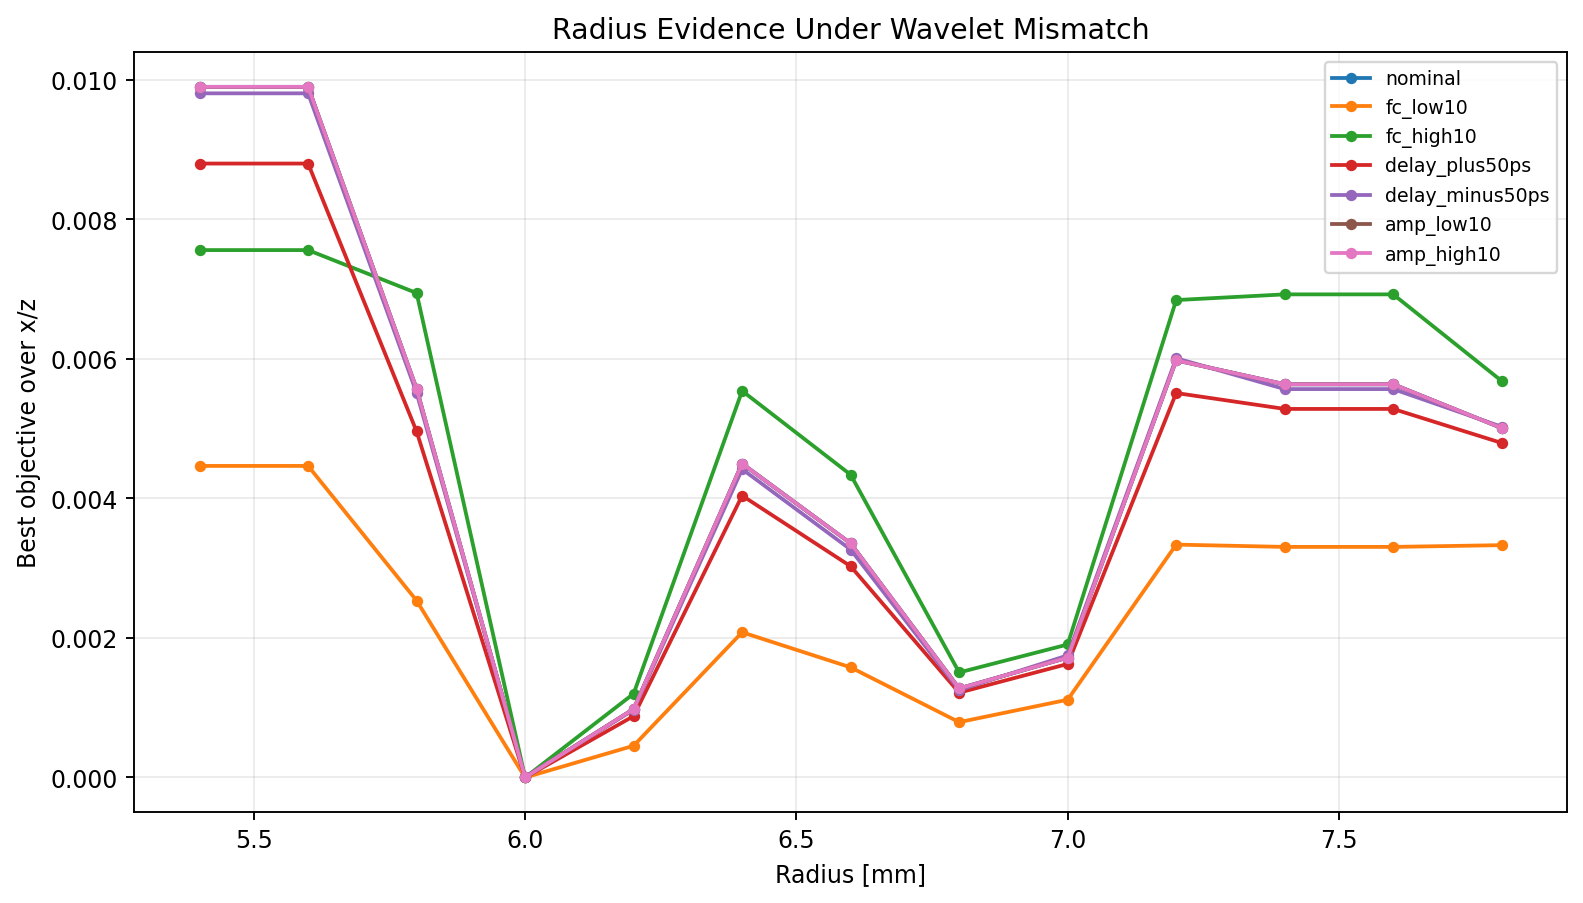

**Figure 1.** Experiment `055` radius profiles after amplitude, time-shift, and frequency-scale profiling. The source-profiled objective returns the minimum to the true 6.0 mm radius across the tested source mismatch cases.


## Milestone 2: Paper-Backed Objective Tests

We evaluated several paper-backed objective ideas before promoting any of them into the main workflow.

Our results showed:

- Progressive bandwidth and frequency weighting are useful diagnostics.
- Low frequencies are valuable for basin finding but are too weak for final radius separation when averaged naively.
- W2/optimal-transport style distances were useful on simple shifted traces but did not improve the actual rebar-radius landscape enough to replace least-squares.
- Full wavefield-reconstruction inversion and implicit neural inversion remain future research branches rather than the immediate solution for this low-dimensional geometry problem.

The resulting design choice was conservative: we use source-profiled least-squares as the final objective, supported by frequency diagnostics and explicit confidence reporting.

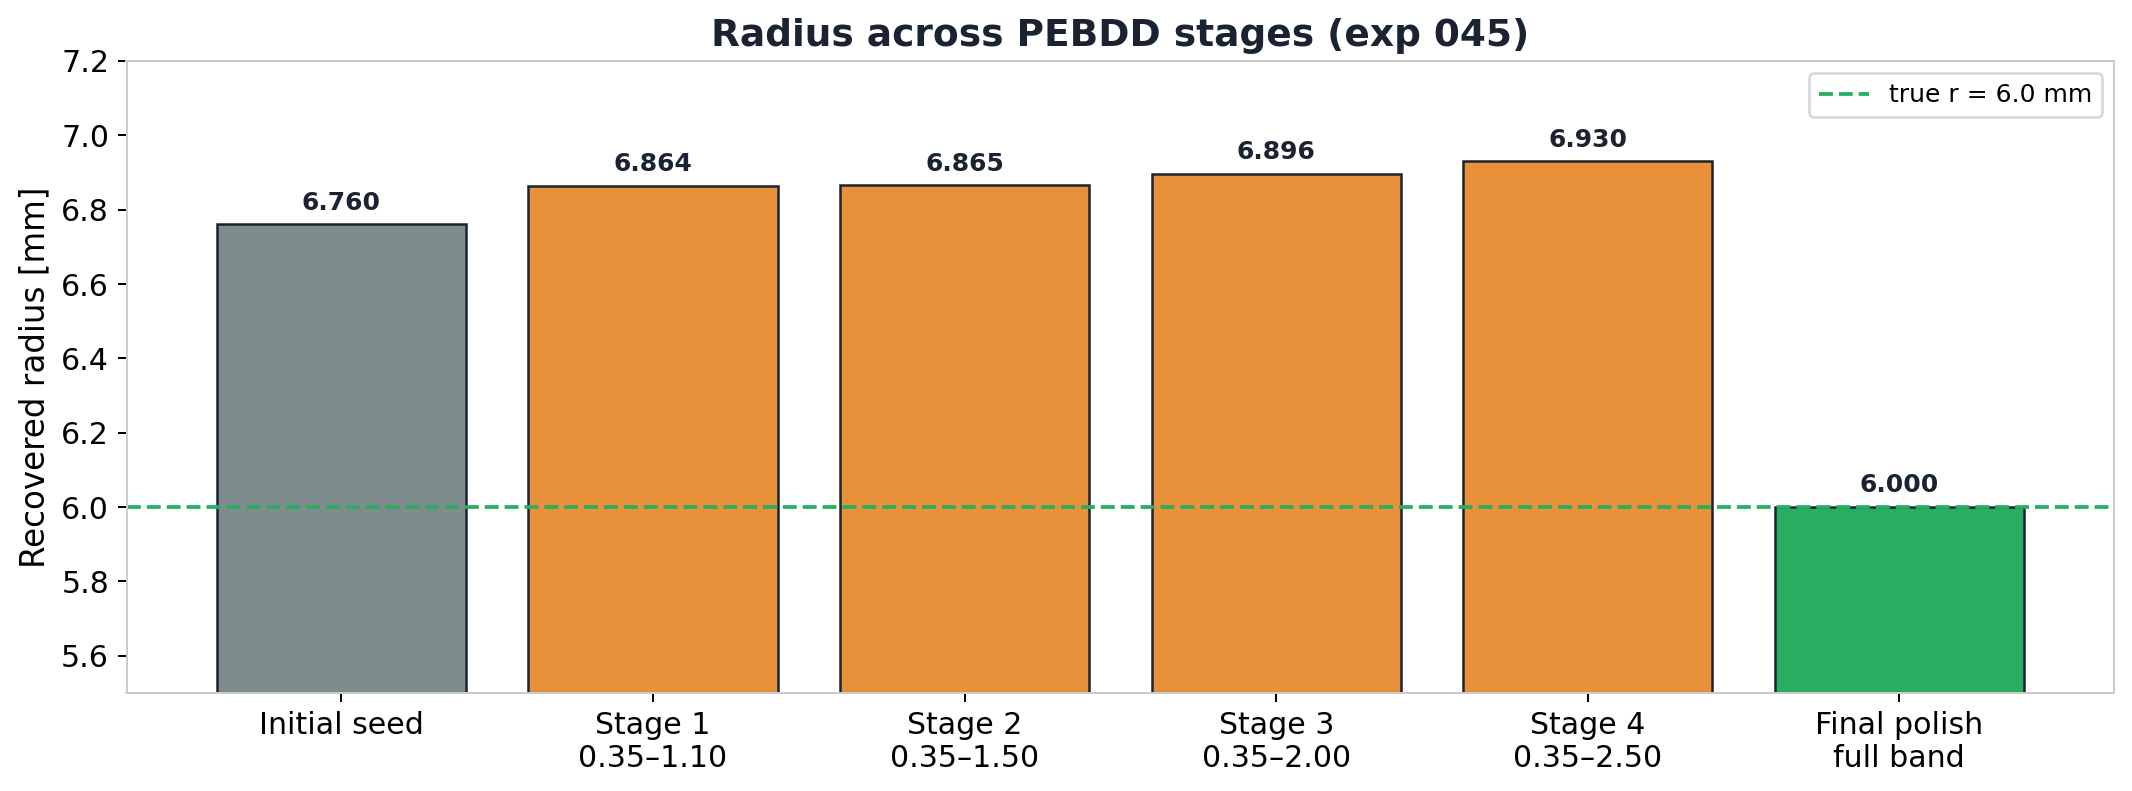

**Figure 2.** Bandwidth-stage summary. Lower-frequency information helps guide the search, while final radius evidence needs higher-frequency content and candidate-margin reporting.


## Milestone 3: Detector-Seeded Single-Rebar Pipeline

We added a B-scan detector so that the inversion pipeline does not require manually specified x/z windows. The detector estimates likely rebar positions from hyperbola-like energy in the B-scan. Radius is then resolved by FWI refinement.

The packaged single-rebar pipeline became:

```text
detector -> 2 mm coarse screen -> 1 mm fine polish -> optional high-band polish -> optional material/source uncertainty report
```

Key outcomes:

- The detector achieved 48/48 hits in the tested single-rebar depth/radius/noise benchmark.
- The detector achieved 48/48 hits in the source-mismatch benchmark.
- The high-band packaged pipeline recovered exact point estimates for tested shallow r=4 mm and deeper r=8 mm cases.
- Material/source uncertainty reporting clarified where a point estimate is best reported together with a wider interval.

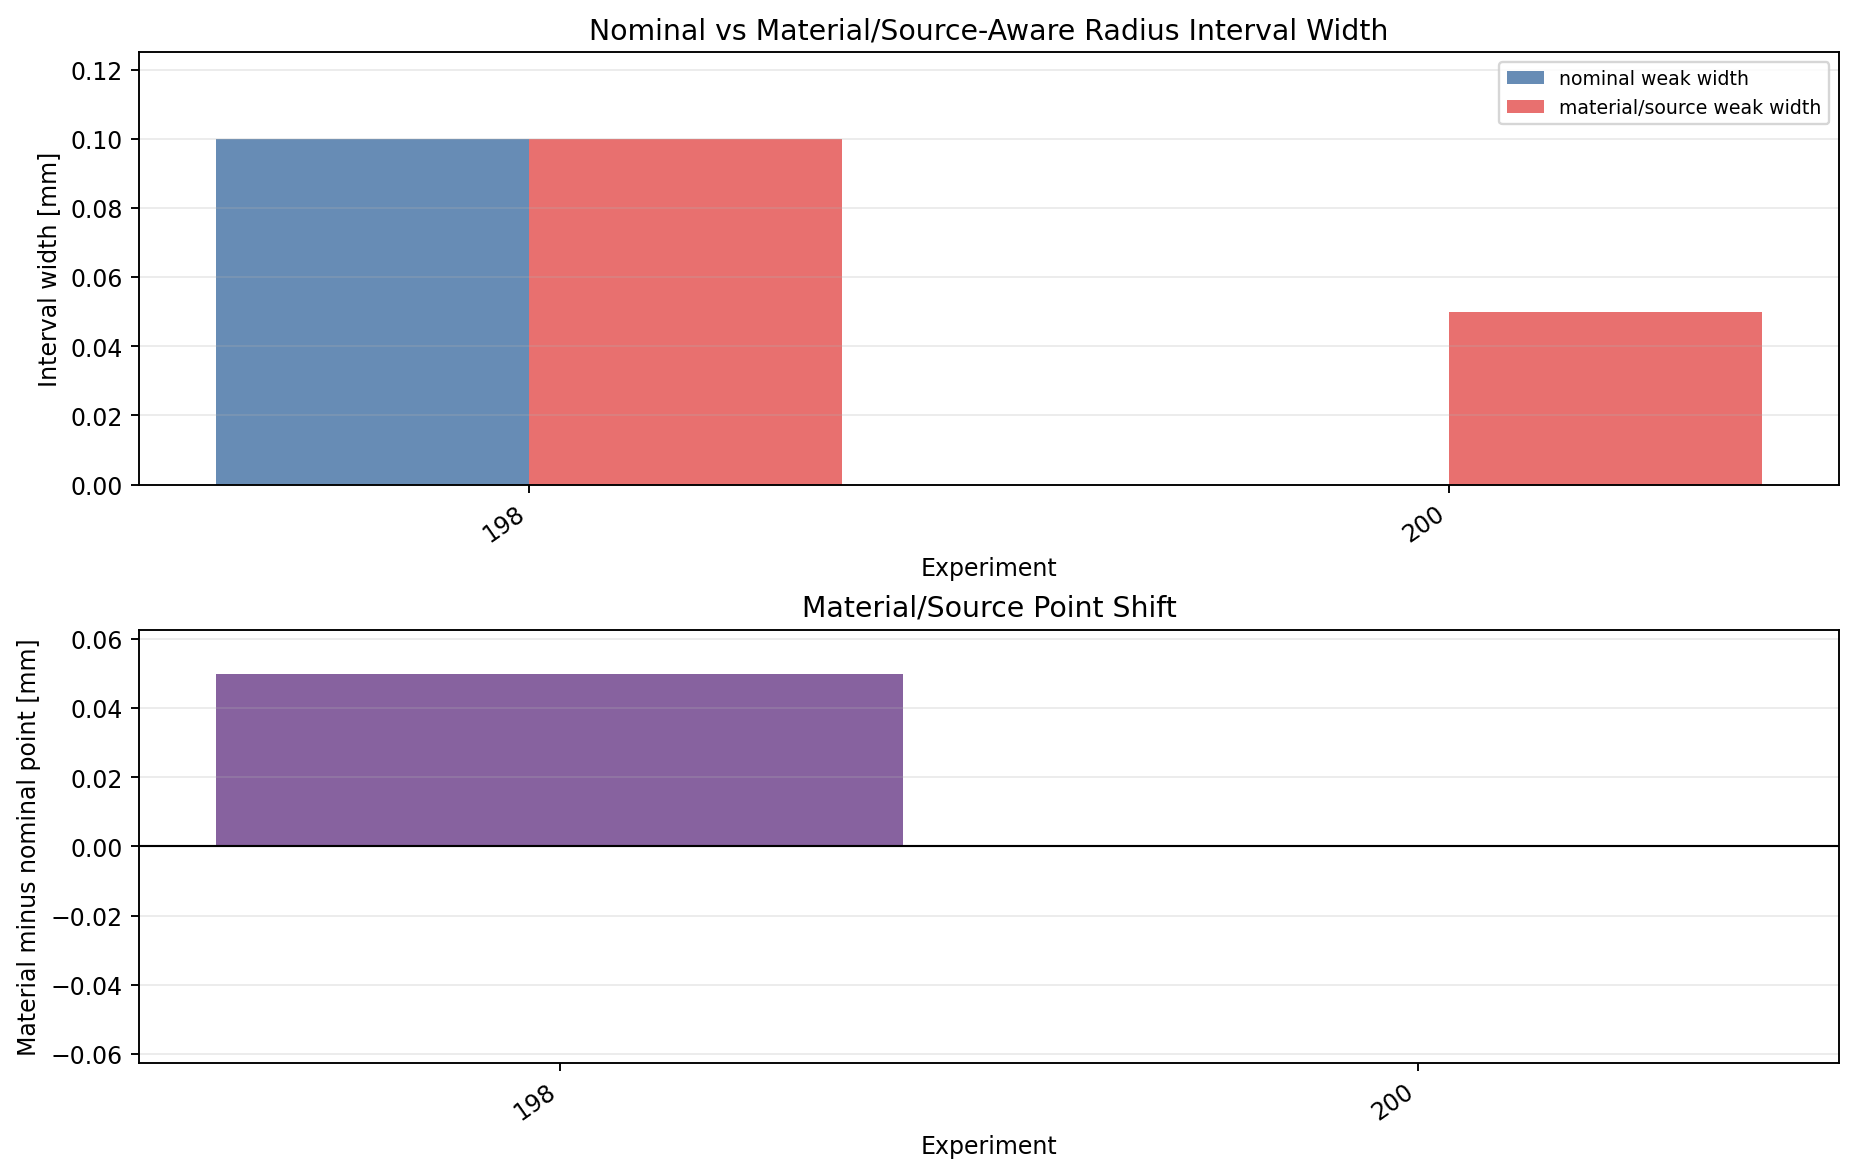

**Figure 3.** Experiment `201` compares nominal high-band radius intervals with material/source-aware intervals. The nominal point estimate can be exact while the calibrated reporting interval widens.

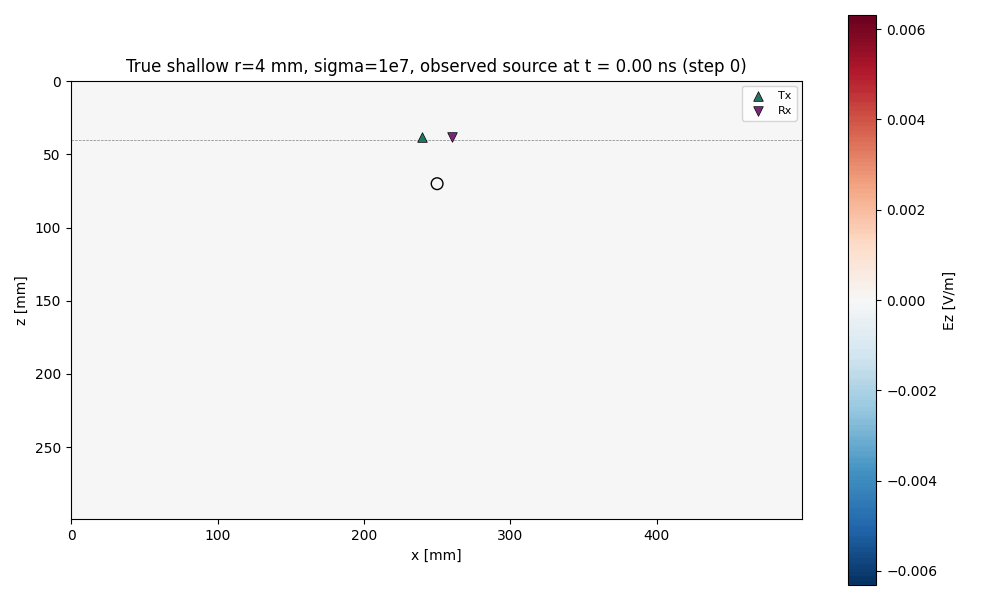

**Figure 4.** Representative wavefield animation from experiment `194` for the shallow 4 mm material/source tradeoff branch.


## Milestone 4: Multi-Rebar Confidence Reporting

We extended the source-profiled workflow from one rebar to a controlled three-rebar scene. The first multi-rebar stages held x/z fixed, then relaxed one target radius at a time, then introduced local x/z/r coupling.

A central result was:

```text
24/24 local multi-rebar target/case rows recovered true x, z, and radius,
but 22/24 rows had weak confidence margins.
```

This is scientifically important. It means the best point can be correct while nearby candidates remain plausible. Our multi-rebar reports therefore include confidence labels and ambiguity intervals by default.

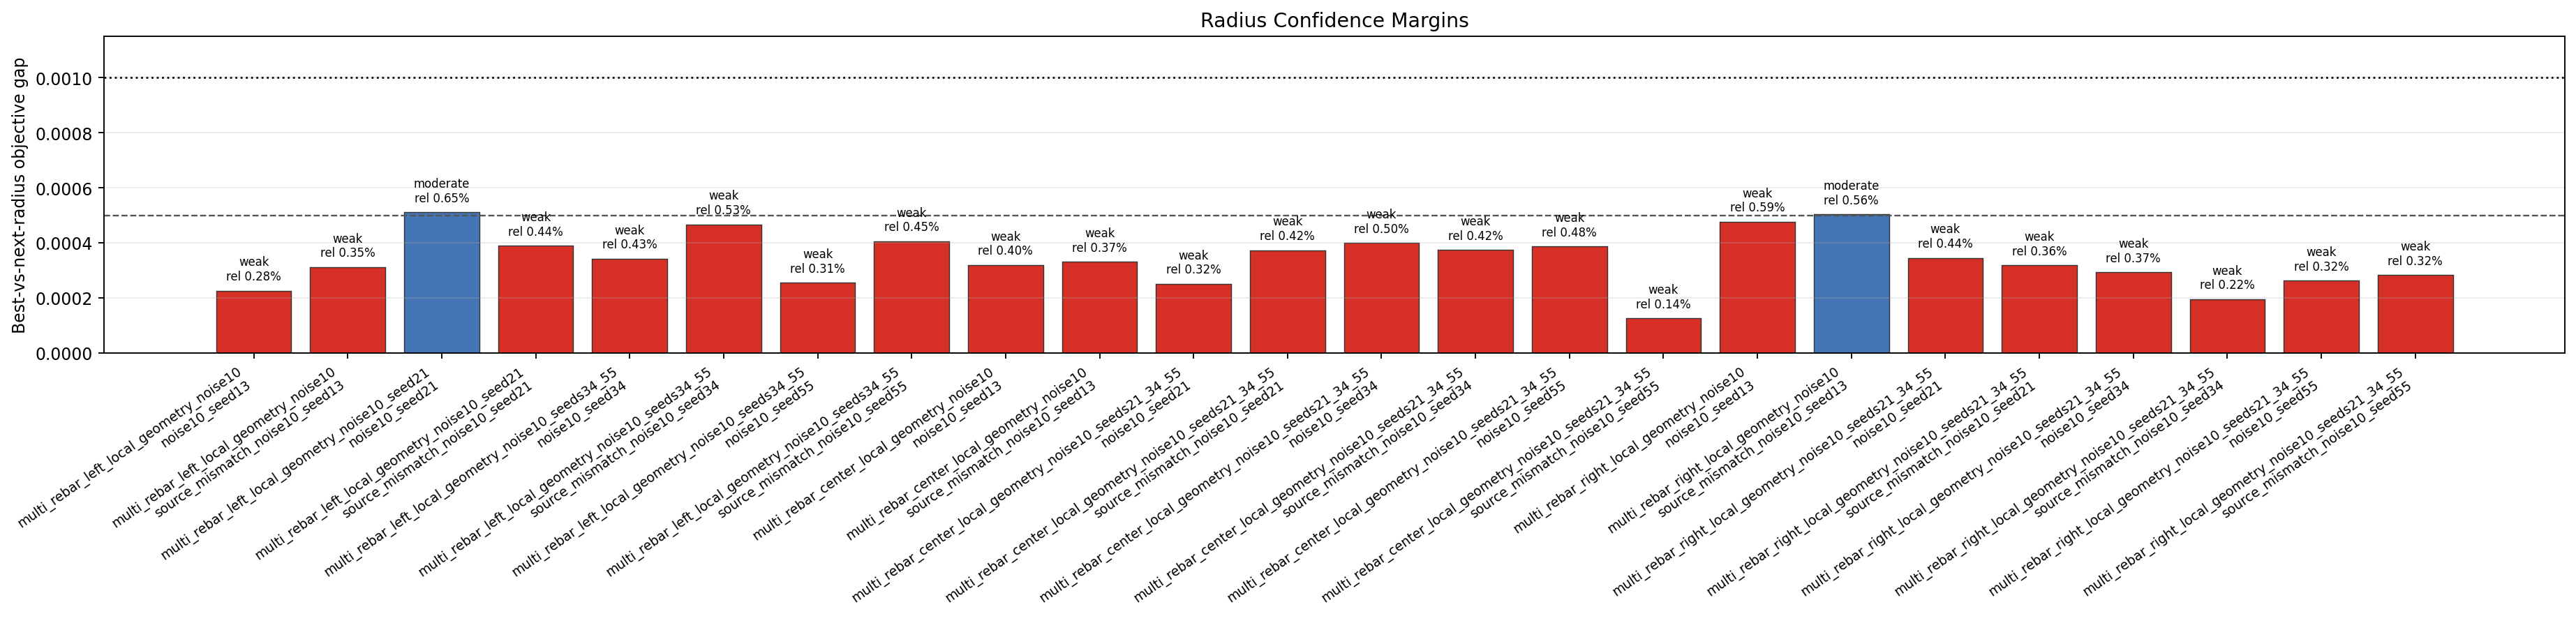

**Figure 5.** Experiment `080` radius confidence margins. Most rows are correct but weak, supporting interval-based reporting rather than point-only reporting.


## Milestone 5: Reporting-First Coordinate Optimizer

The multi-rebar coordinate optimizer updates one target at a time. Each update writes its candidate table, confidence label, fallback warning, ambiguity interval, and selected source profile.

This design allowed us to identify a specific failure mode in wider seed-offset tests: edge targets can select a deeper/larger-radius branch when neighboring target estimates are still imperfect. Guarded revisits correct many of these cases after the other targets are updated.

The important design lesson is that objective weighting alone is complementary to staged correction. High-band variants improve confidence after neighboring geometry is corrected, while early coordinate updates still depend on the staged model state.


## Milestone 6: Detection and Assignment for Variable-Radius Multi-Rebar Scenes

We then moved toward an end-to-end multi-rebar workflow:

```text
B-scan detection -> detection-to-target assignment -> coordinate refinement -> joint-radius reporting
```

The variable-radius close-spacing branch used three rebars with different sizes:

```text
x = [190, 250, 310] mm
z = [90, 90, 90] mm
r = [5, 6, 8] mm
```

This branch combined source mismatch, 10% noise, and multi-target interference. It showed that detection could seed the right regions, but the large right target required focused refinement and joint-radius reporting.

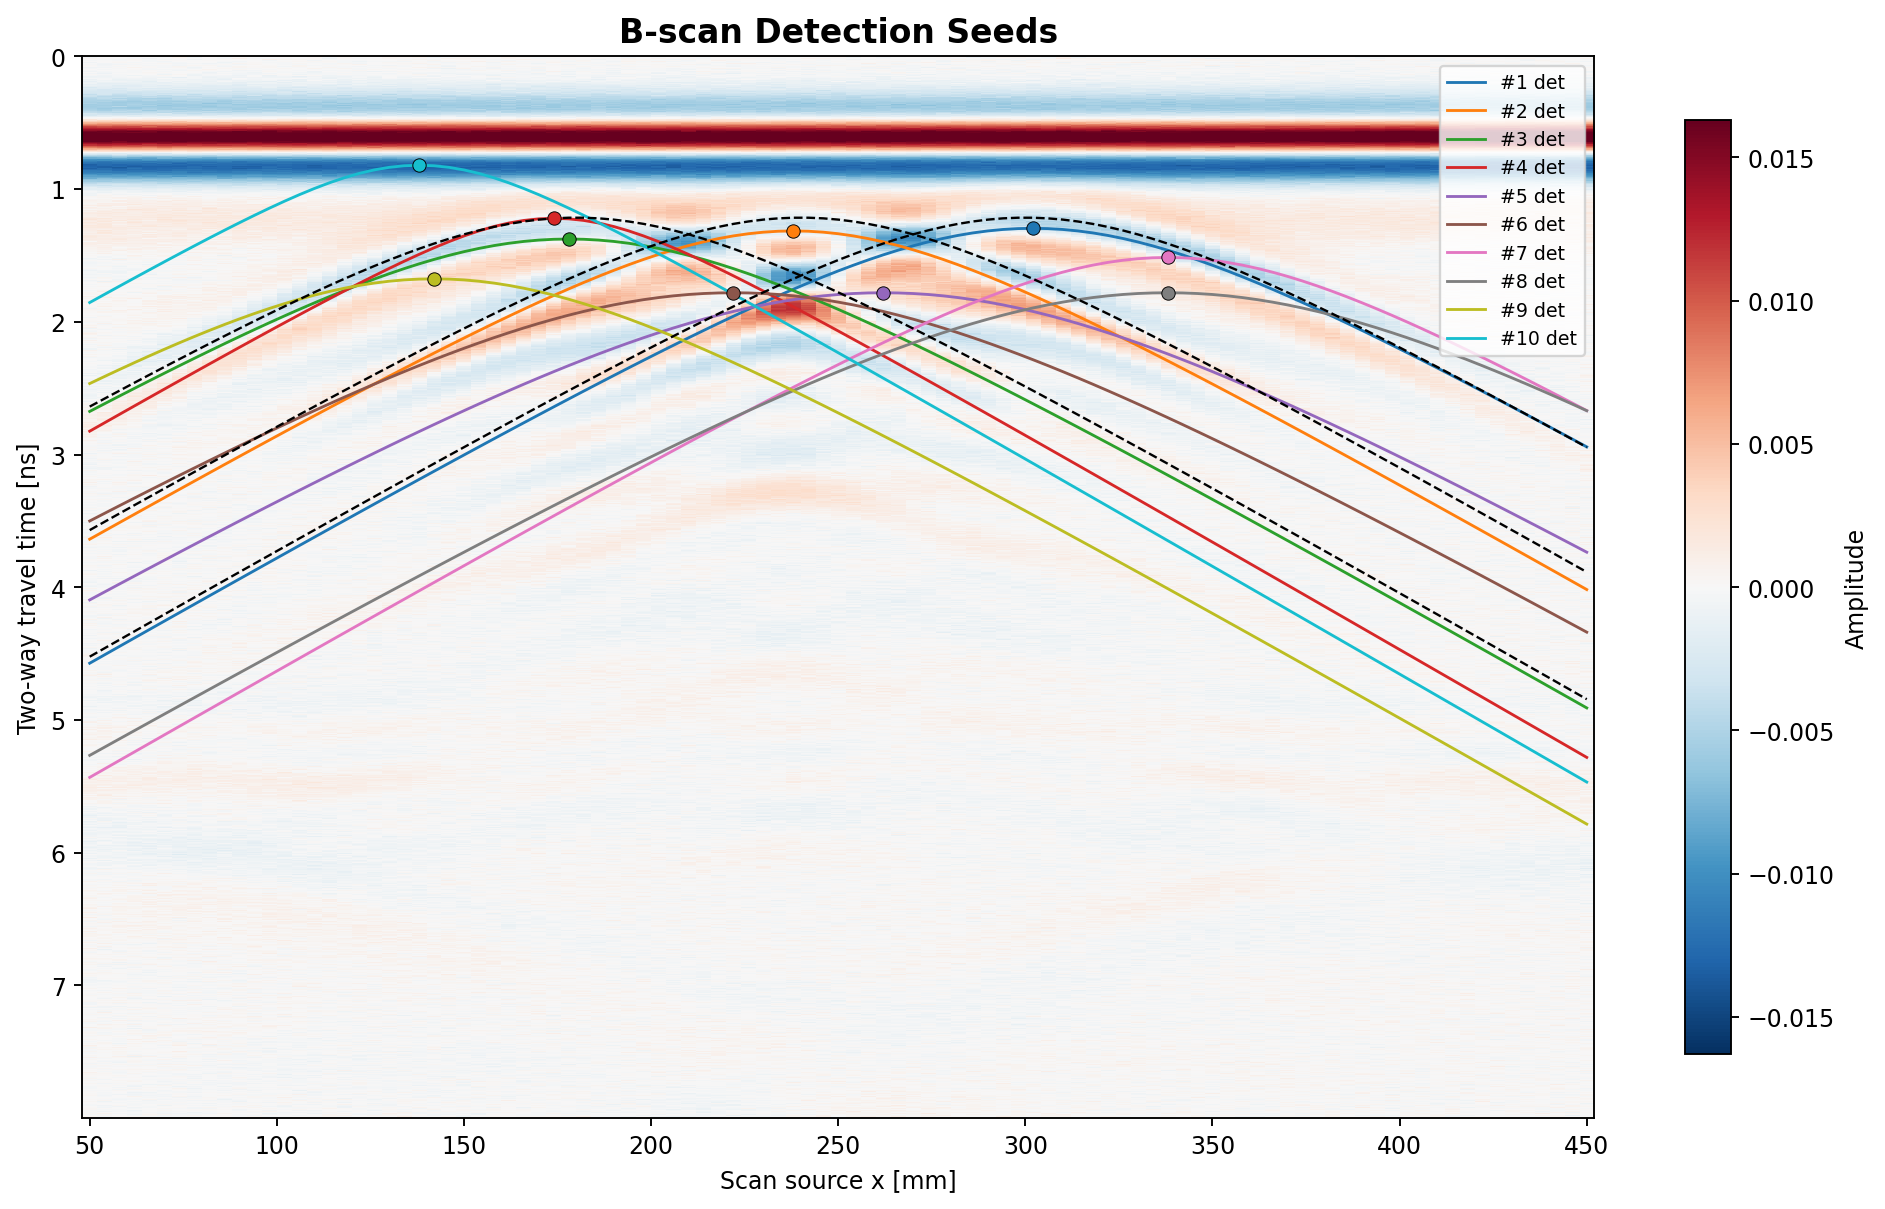

**Figure 6.** Experiment `216` detector overlay for the variable-radius close-spacing branch. Candidate hyperbolas are overlaid on the B-scan to provide seed windows for refinement.


## Current Main Branch: Variable-Radius Close-Spacing Pipeline

For the close-60 mm variable-radius branch, the staged pipeline used detection, location-only refinement, focused target-2 refinement, and joint-radius profiling.

Our results show:

- Seeds 13 and 21 recovered the true joint radius tuple `[5, 6, 8]`.
- Seed 34 initially showed a 1 mm lateral ambiguity for the right target.
- A 7-source focused refinement removed that 1 mm ambiguity and returned the true final tuple.

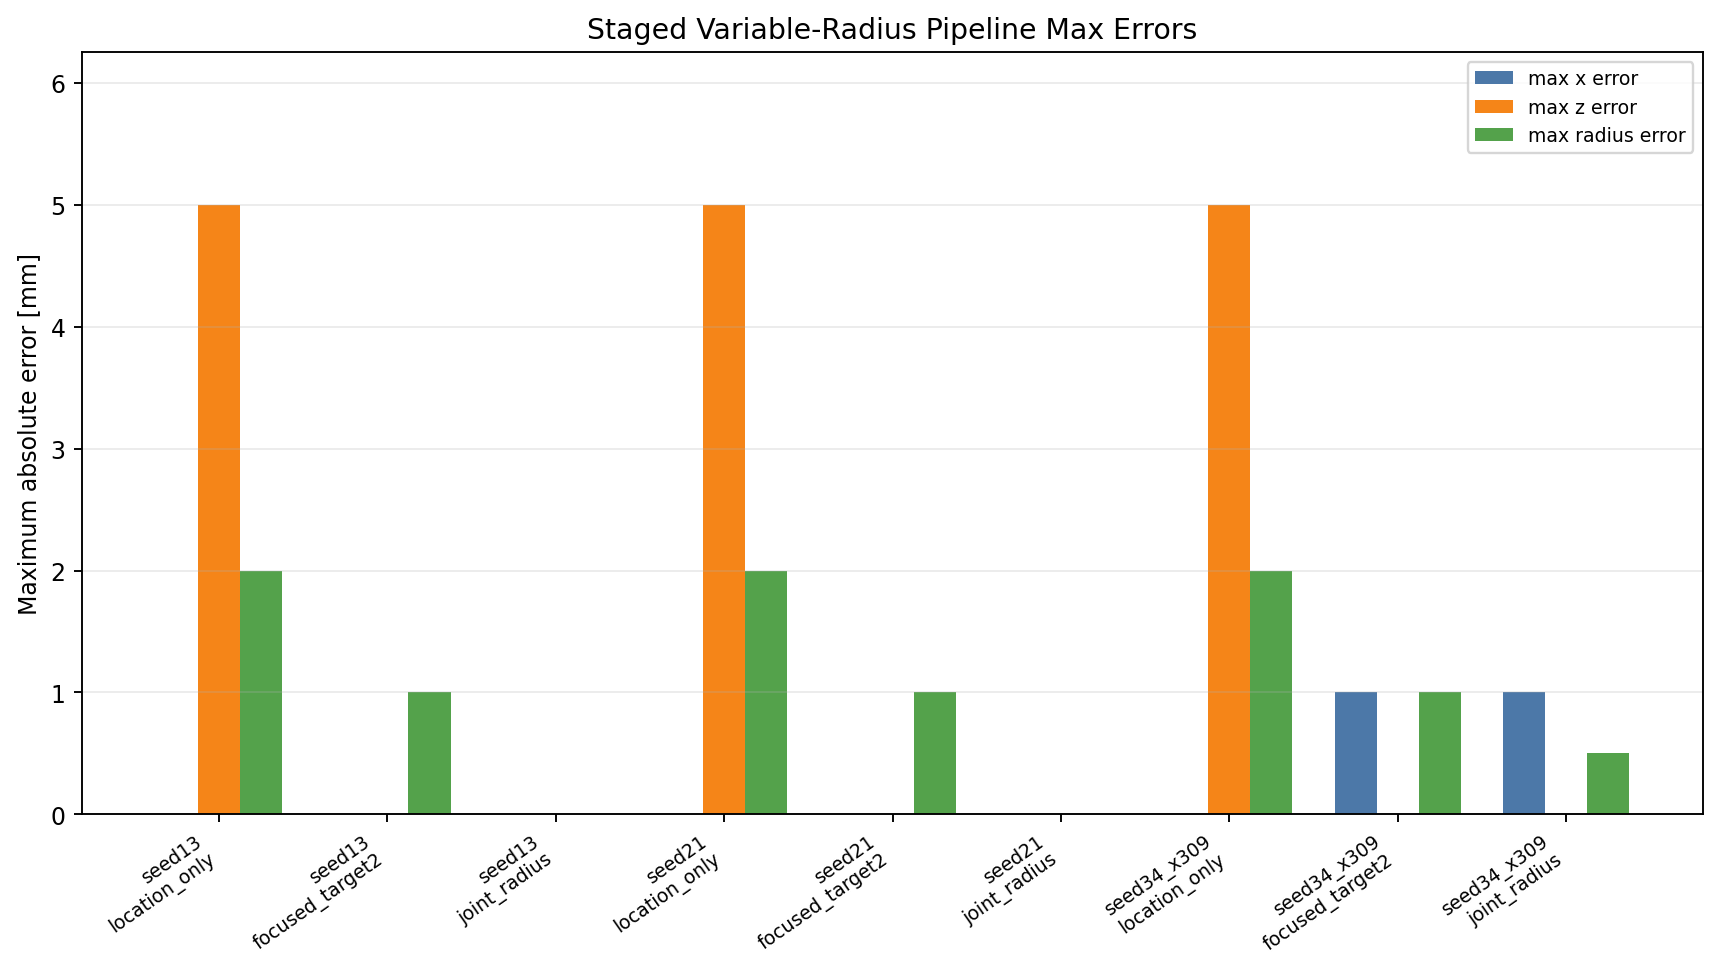

**Figure 7.** Experiment `248` staged error summary. Location-only refinement reduces x/z errors, but radius recovery requires focused and joint-radius stages.


## Latest Completed Branch: Close-50 mm Acquisition Design

The latest completed branch tightens the spacing further:

```text
x = [190, 250, 300] mm
z = [90, 90, 90] mm
r = [5, 6, 8] mm
```

The hard target is the rightmost rebar at `x=300 mm`, `r=8 mm`. The nearest competing branch is around `x=299 mm` with a smaller radius. The research question became acquisition design: how many scan positions and what Tx/Rx offset are needed to separate those two branches?

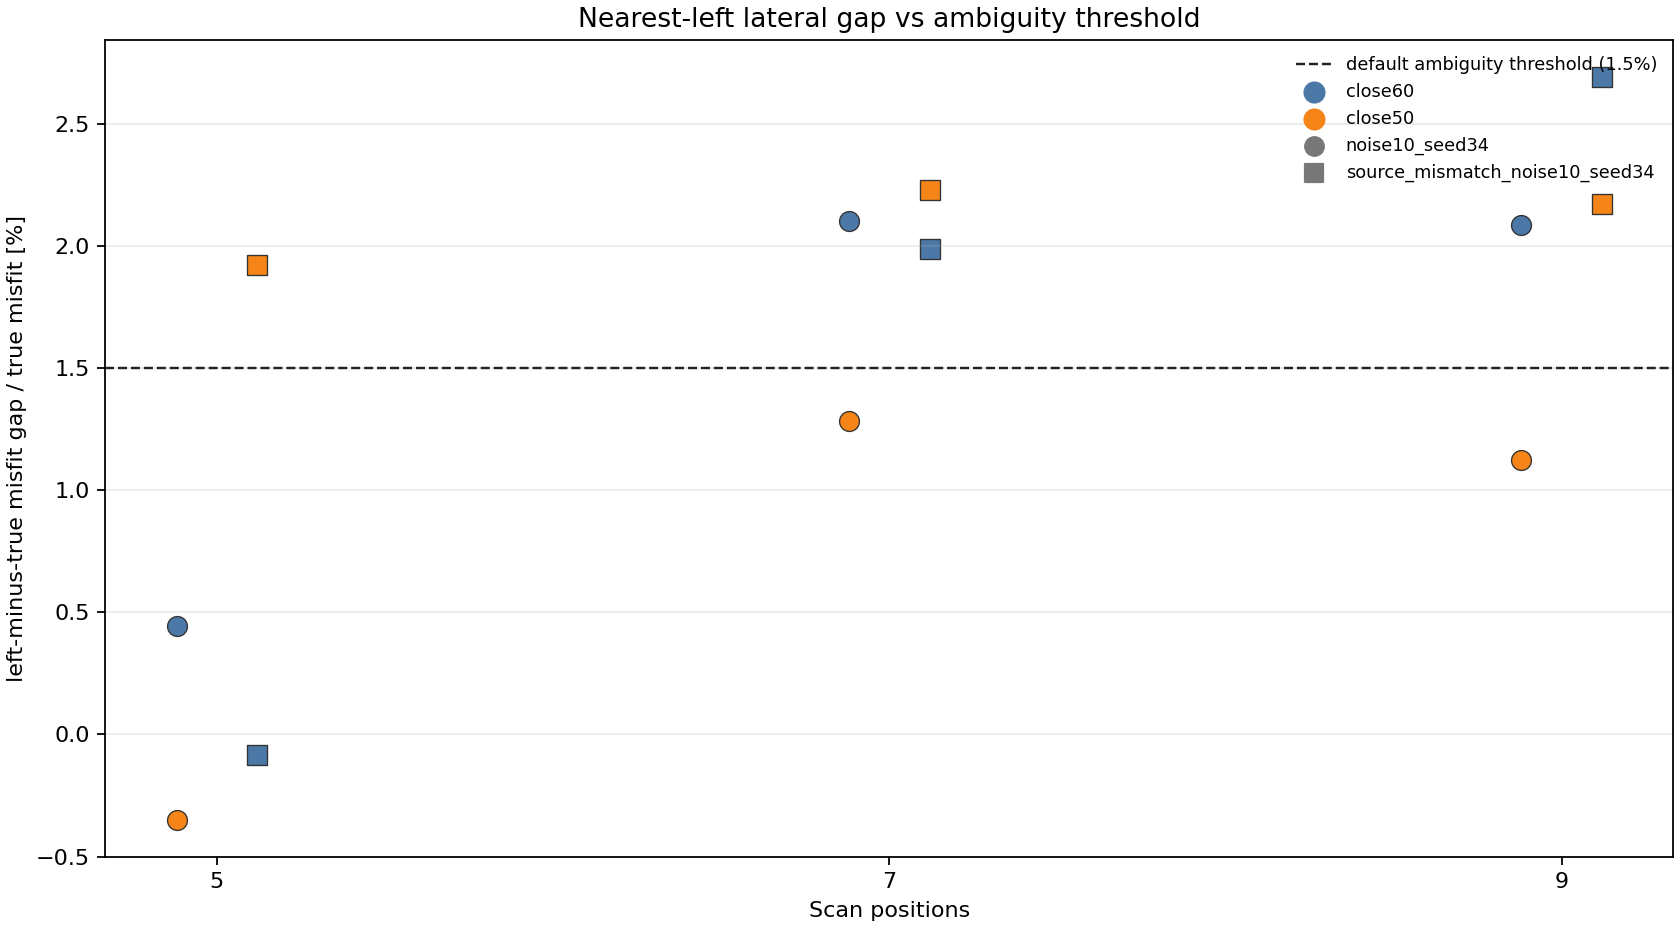

**Figure 8.** Experiment `263` compares the true right-target x position against the nearest-left competitor. Points above the dashed 1.5% line are separated enough to avoid being reported as ambiguous.


## Key Current Finding: 40 mm Tx/Rx Offset Improves Separation

The strongest completed acquisition result is the 40 mm Tx/Rx offset branch.

With 5 scan positions and 40 mm Tx/Rx offset:

- Seeds 13, 21, and 34 all prefer the true `x=300 mm` target over the `x=299 mm` competitor.
- The base objective clears the 1.5% ambiguity threshold in every tested row.
- The high-band diagnostic objective increases the separation further.

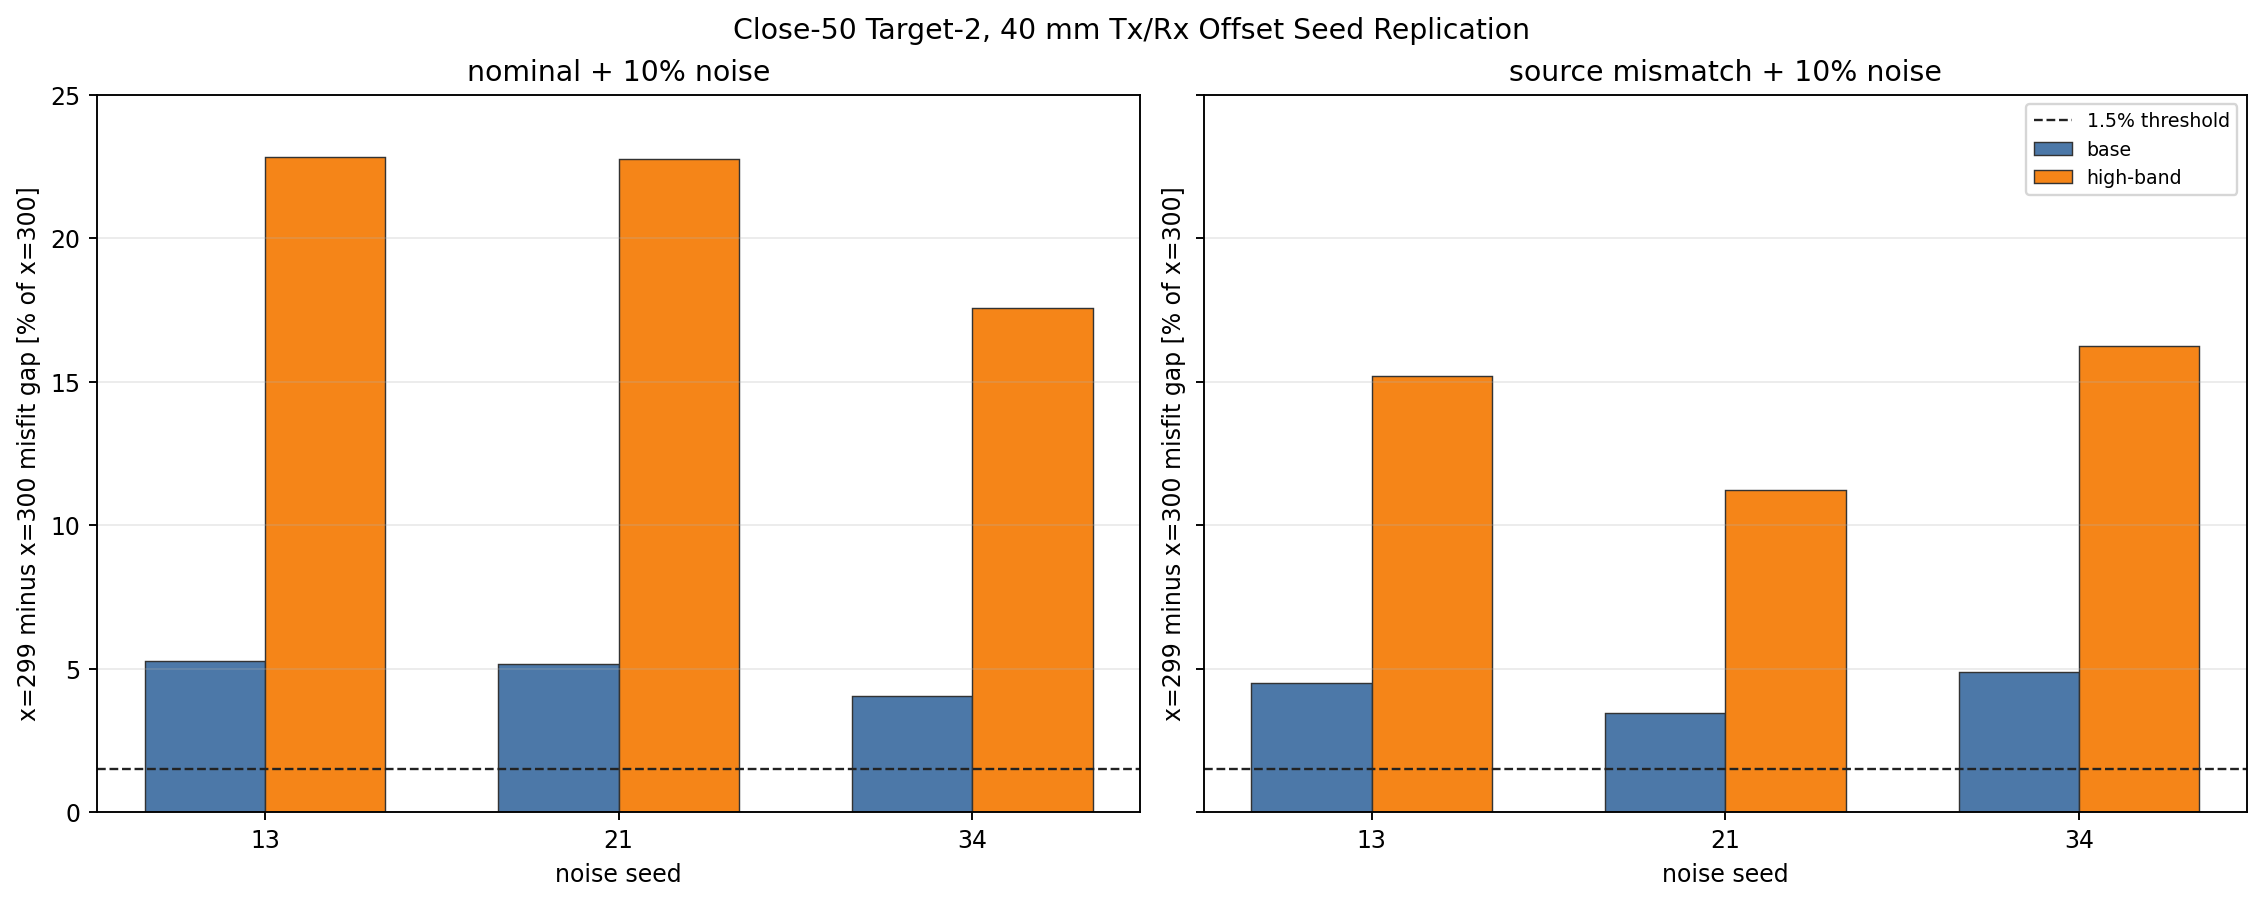

**Figure 9.** Experiment `271` seed replication for close-50 target 2 with 5 scan positions and 40 mm Tx/Rx offset. Positive bars indicate that the true `x=300 mm` candidate is preferred over the `x=299 mm` competitor.


## Ongoing Experiment: 4 Sources Between the Failed and Successful Settings

Completed runs show a clear acquisition-density boundary:

- 3 sources with 40 mm Tx/Rx offset are insufficient. The optimizer prefers `x=299 mm`, `r=7.5 mm` in the tested seed-34 rows.
- 5 sources with 40 mm Tx/Rx offset are successful. The optimizer returns `x=300 mm`, `r=8.0 mm` with strong radius confidence and no x ambiguity in the tested 40 mm-offset rows.
- Experiment `276` is currently testing 4 sources with 40 mm Tx/Rx offset to determine whether it is a viable minimum acquisition setting.

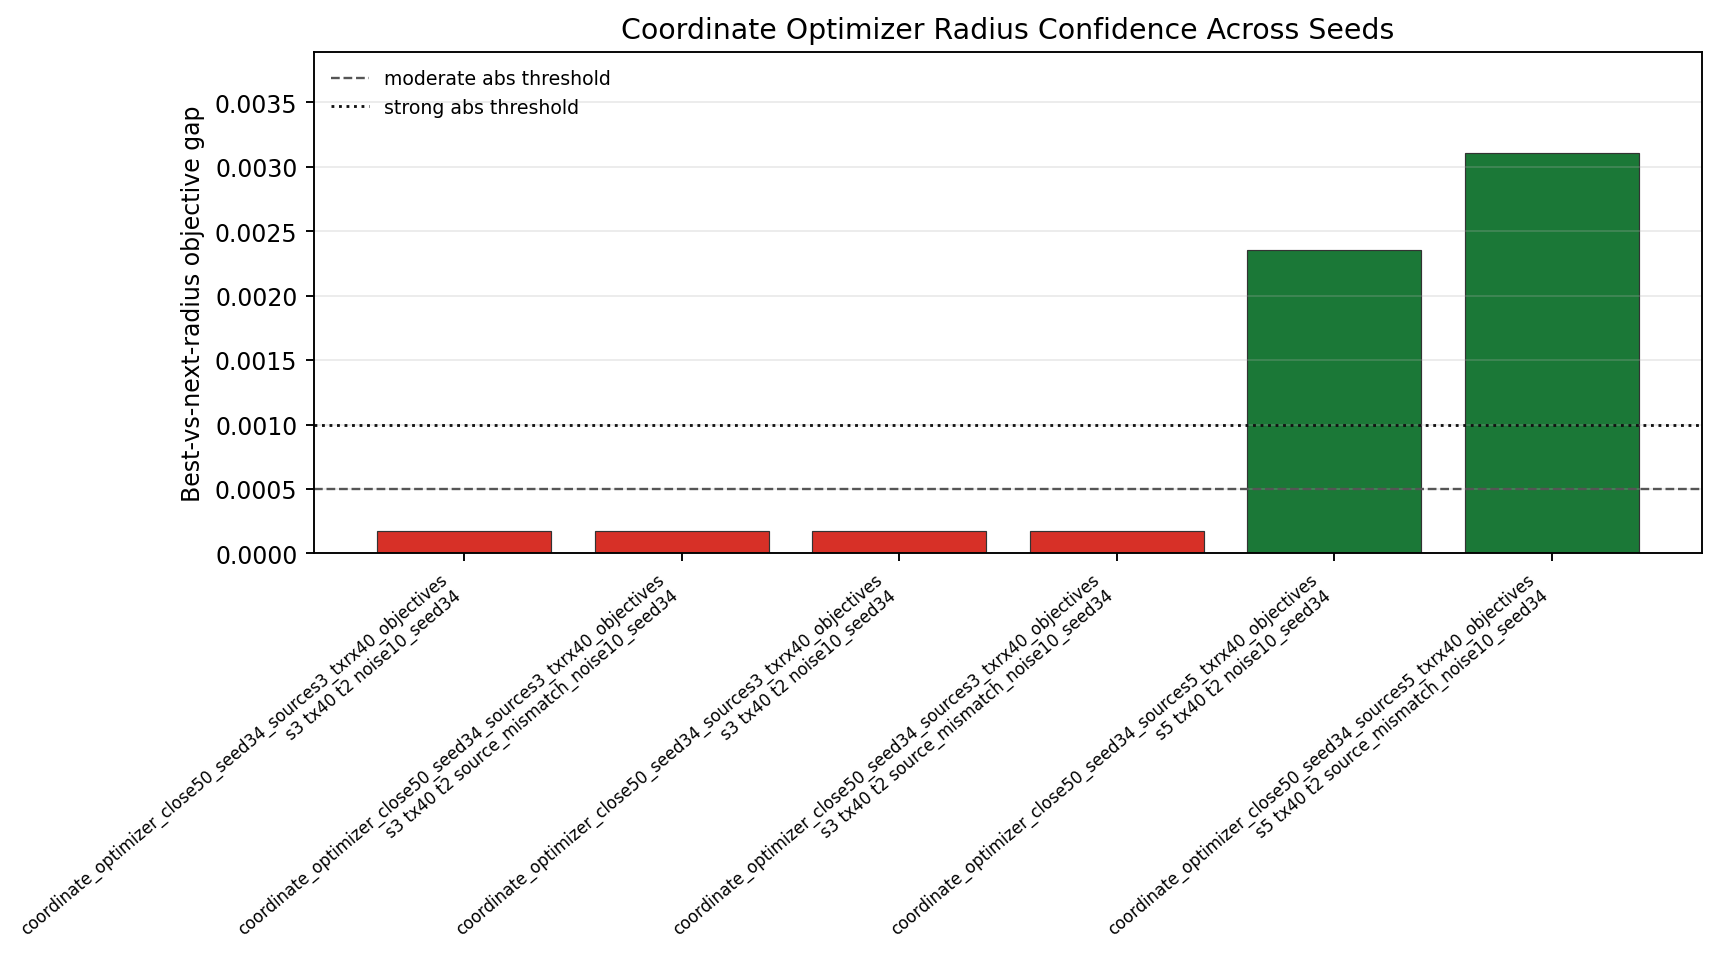

**Figure 10.** Experiment `275` compares 3-source and 5-source 40 mm-offset results. Red bars are weak 3-source rows; green bars are strong 5-source rows. This motivates the active 4-source experiment.


## Current Objective and Reporting Stack

| Component | Current role | Status |
| --- | --- | --- |
| Source-profiled least-squares | Main final data-misfit objective with source amplitude, time shift, and frequency-scale profiling | Primary working objective |
| Detector hyperbola score | Produces x/z seed windows from B-scans | Working seed layer |
| Base coordinate objective | 1.5 GHz source-profiled local x/z/r score | Main multi-rebar coordinate score |
| High-band diagnostic objective | Higher-frequency or high-band score for candidate separation | Useful for confidence and final polish, not a universal replacement |
| Guarded revisit | Rechecks weak edge-target updates after neighboring geometry improves | Important for wider seed offsets |
| Confidence report | Converts top candidates into labels and ambiguity intervals | Required output |
| Material/source uncertainty report | Adds nuisance-aware radius interval reporting | Optional calibration/reporting layer |
| W2/optimal transport | Alternative waveform distance tested from papers | Not promoted for final radius selection |


## Forward Plan

The immediate next decision depends on experiment `276`.

If 4 sources with 40 mm Tx/Rx offset succeeds, our next step is to aggregate 3-, 4-, and 5-source settings and replicate the 4-source result across seeds. That would define a candidate minimum acquisition design for the close-50 mm target-2 problem.

If 4 sources remains ambiguous, our current evidence supports 5 sources with 40 mm Tx/Rx offset as the minimum reliable setting for this synthetic close-50 branch.

After that decision, the planned work is:

1. Integrate the selected acquisition setting back into the full staged variable-radius pipeline.
2. Extend the close-50 analysis beyond target 2 and beyond seed 34.
3. Continue reporting confidence intervals and material/source-aware intervals in final results.
4. Update the long-form experiment tracker so recent runs `202-276` are summarized in the same prose style as earlier stages.
5. Prepare a compact benchmark matrix suitable for a research manuscript or advisor review.


## References and Traceability

This report is traceable to the repository experiment archive:

```text
docs/experiments/
outputs/experiments/
docs/papers/
```

Representative artifact paths:

| Artifact | Canonical path |
| --- | --- |
| Figure 1 | `outputs/experiments/055_wavelet_mismatch_radius_amp_time_freqfit/figures/wavelet_mismatch_radius_profiles.png` |
| Figure 2 | `outputs/presentation_figures_single_rebar_next/pebdd_stage_progression.png` |
| Figure 3 | `outputs/experiments/201_packaged_highband_material_uncertainty_r4_r8_178_200/figures/two_stage_material_uncertainty_summary.png` |
| Figure 4 | `outputs/experiments/194_single_rebar_r4_material_source_tradeoff_highband_subcell13_seed13/figures/true_r4_sigma1e7_observed_source_wavefield.gif` |
| Figure 5 | `outputs/experiments/080_multi_rebar_stage7_ambiguity_interval_report/figures/candidate_confidence_margins.png` |
| Figure 6 | `outputs/experiments/216_detection_multi_rebar_variable_radius_close_spacing_source_mismatch_noise10/figures/detection_overlay.png` |
| Figure 7 | `outputs/experiments/248_variable_radius_staged_pipeline_seed13_21_34_summary/figures/staged_variable_radius_pipeline_errors.png` |
| Figure 8 | `outputs/experiments/263_lateral_gap_threshold_close50_vs_close60_summary/figures/lateral_neighbor_gap_thresholds.png` |
| Figure 9 | `outputs/experiments/271_close50_txrx40_seed_replication_summary/figures/txrx40_seed_gap_replication.png` |
| Figure 10 | `outputs/experiments/275_coordinate_confidence_aggregate_close50_txrx40_sources3_vs5_seed34/figures/coordinate_confidence_aggregate.png` |

External platform references:

- NVIDIA DGX Spark product page: https://www.nvidia.com/en-us/products/workstations/dgx-spark/
- NVIDIA DGX Spark User Guide: https://docs.nvidia.com/dgx/dgx-spark/dgx-spark.pdf
